# Diabetes Prediction — Complete Machine Learning Classification Project

**Project goal:** Predict whether a person has diabetes (`diabetes = 1`) or does not have diabetes (`diabetes = 0`).

This notebook expands the original project by adding:

- Complete EDA
- Data-quality checks
- Class-imbalance analysis
- Train/test split with stratification
- Proper preprocessing using `ColumnTransformer`
- SMOTE oversampling **inside the training pipeline** to avoid data leakage
- Multiple classification algorithms
- Common evaluation metrics
- Confusion matrices and ROC/PR curves
- Model comparison
- Feature importance / coefficients
- Final model saving
- Prediction example
- Presentation-ready explanations and comments



In [49]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


In [50]:
%pip install --upgrade imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [51]:
import sklearn
import imblearn

print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

print("SMOTE imported successfully!")

scikit-learn: 1.9.0
imbalanced-learn: 0.14.2
SMOTE imported successfully!


In [52]:
 pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [53]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC 
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

import joblib

# SMOTE is provided by imbalanced-learn.
# If this import gives ModuleNotFoundError, run:
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the dataset

The target column is **`diabetes`**:
- `0` → no diabetes
- `1` → diabetes


In [54]:
# ============================================================
# 2. LOAD DATA
# ============================================================

#DATA_PATH = "diabetes_prediction_dataset.xls"

DATA_PATH = "diabetes_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully.
Shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### What we are checking

`shape` tells us the number of rows and columns.




In [55]:
df.shape

(100000, 9)

> "Initially, the dataset contained 100,000 records and 9 columns."



In [56]:
# Basic information about columns, data types and non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [57]:
# Statistical summary of numerical columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


In [58]:
# Check the column names
print("Columns:")
for col in df.columns:
    print("-", col)


Columns:
- gender
- age
- hypertension
- heart_disease
- smoking_history
- bmi
- HbA1c_level
- blood_glucose_level
- diabetes


# 3. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset **before building a model**.

We will check:
1. Missing values
2. Duplicate rows
3. Target distribution
4. Numerical distributions
5. Categorical distributions
6. Outliers
7. Relationships/correlations
8. Class imbalance


In [59]:
# ============================================================
# 3.1 MISSING VALUES
# ============================================================

missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_percent
})

missing_table


,Missing_Count,Missing_Percent
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0


### Observation

There are no missing values in any of the columns

Even when the current dataset has no missing values, the final ML pipeline below includes an imputer. This makes the workflow safer if future data contains missing values.


In [60]:
# ============================================================
# 3.2 DUPLICATE ROWS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:", round(duplicate_count / len(df) * 100, 2), "%")


Number of duplicate rows: 3854
Percentage of duplicate rows: 3.85 %


In [61]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (96146, 9)


### Why check duplicates?

Duplicate records can give repeated examples more influence during training.

"I found 3,854 duplicate rows, which represented 3.85% of the original dataset."

"After removing the duplicates, the dataset contained 96,146 records and 9 columns."


In [62]:
# ============================================================
# 3.3 TARGET DISTRIBUTION
# ============================================================

target_counts = df["diabetes"].value_counts().sort_index()
target_percent = df["diabetes"].value_counts(normalize=True).sort_index() * 100

target_table = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

target_table


,Count,Percentage
diabetes,,
0,87664,91.18
1,8482,8.82


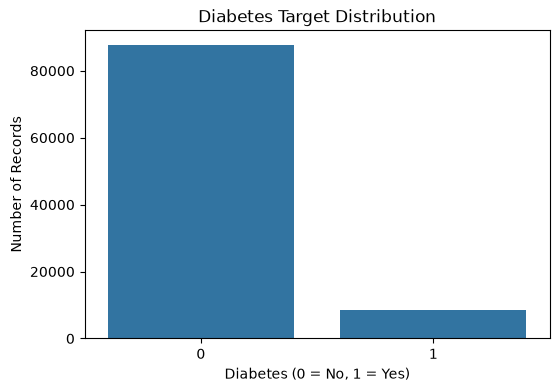

In [63]:
# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diabetes")
plt.title("Diabetes Target Distribution")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")
plt.show()


### Important class-imbalance observation

The dataset contains approximately:

- **91.18%** non-diabetic records (`0`)
- **8.82%** diabetic records (`1`)

Therefore, the target is **imbalanced**.

If we train a model without considering this imbalance, accuracy alone can be misleading. A model could predict many people as non-diabetic and still obtain high accuracy.

For a medical classification problem, **recall, precision, F1-score, ROC-AUC and especially PR-AUC** are useful additional metrics.


In [64]:
# ============================================================
# 3.4 NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove target from the numerical predictor list
numerical_features = [c for c in numerical_cols if c != "diabetes"]

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_features)


Categorical features: ['gender', 'smoking_history']
Numerical features: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


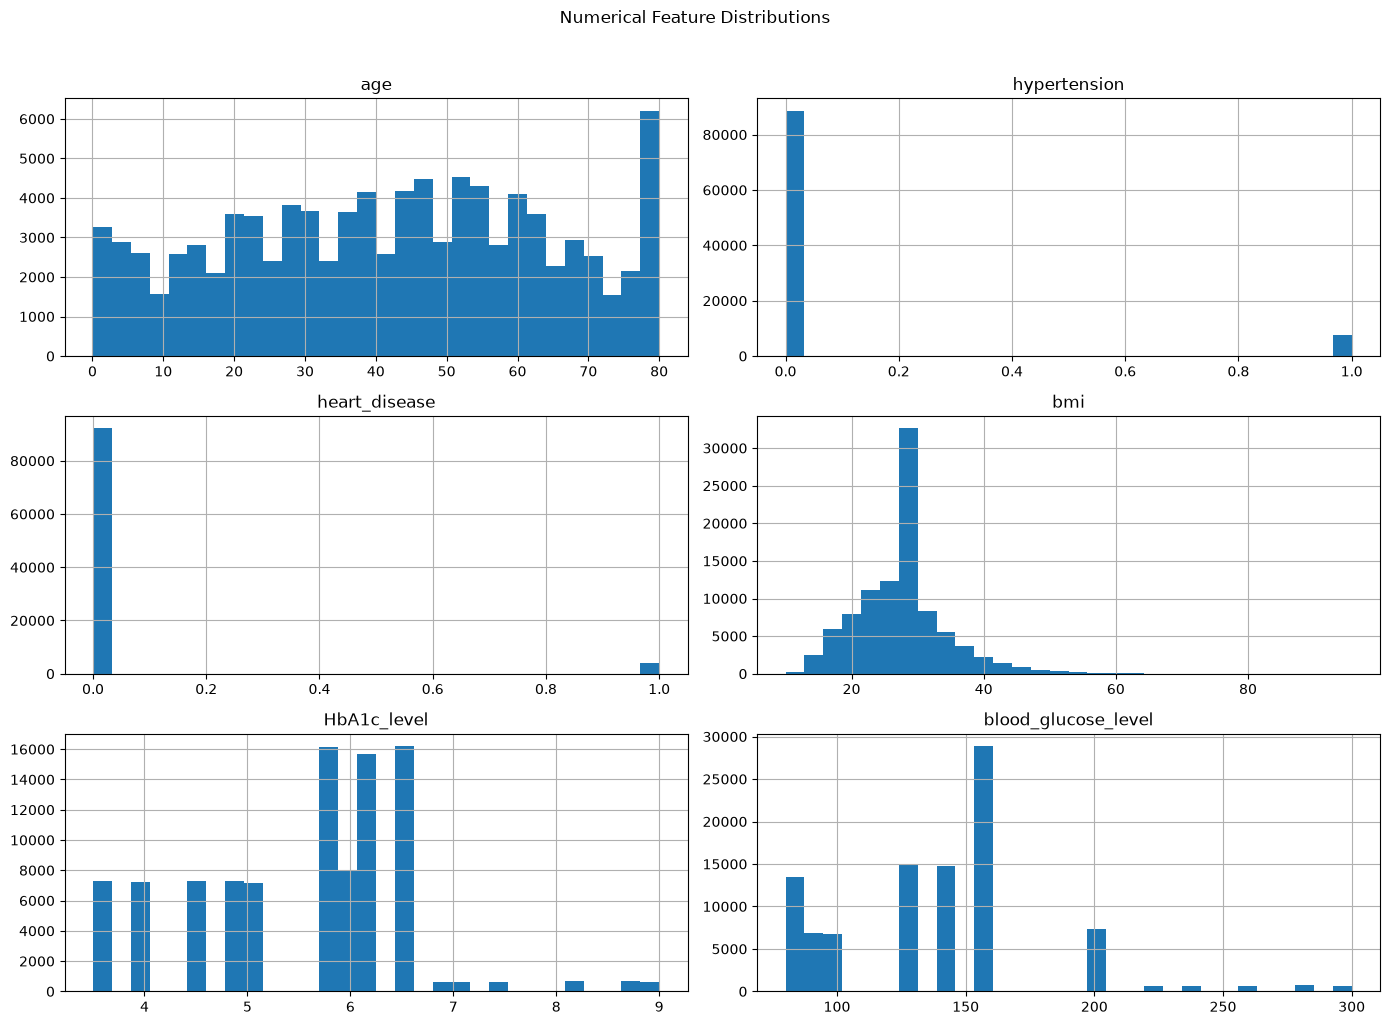

In [65]:
# ============================================================
# 3.5 NUMERICAL DISTRIBUTIONS
# ============================================================

df[numerical_features].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


Histograms show the distribution of numerical variables such as age, BMI, HbA1c level and blood glucose level.

They help us identify:
- skewness
- unusual values
- spread of the data
- possible outliers


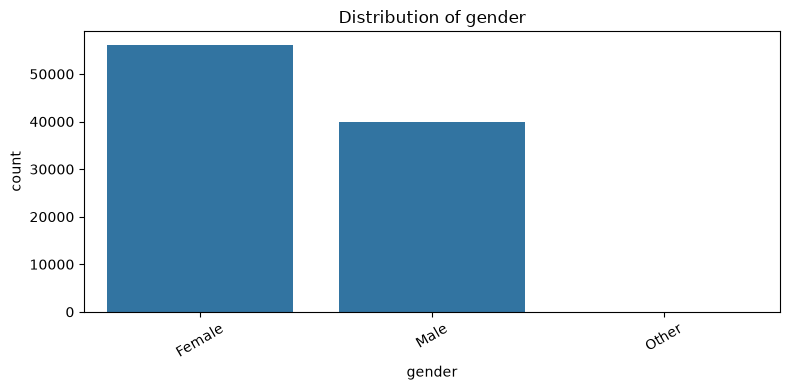

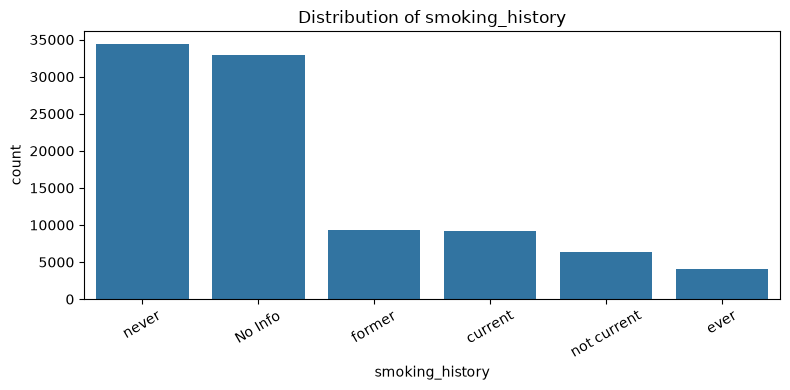

In [66]:
# ============================================================
# 3.6 CATEGORICAL FEATURE DISTRIBUTIONS
# ============================================================

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


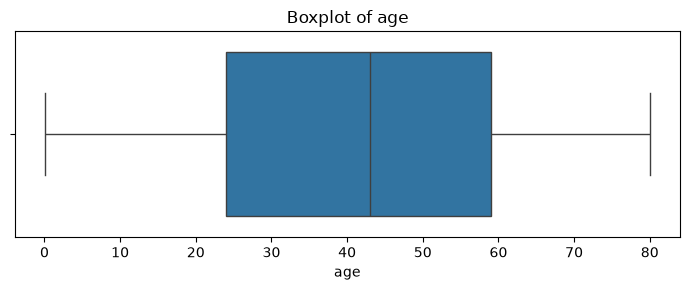

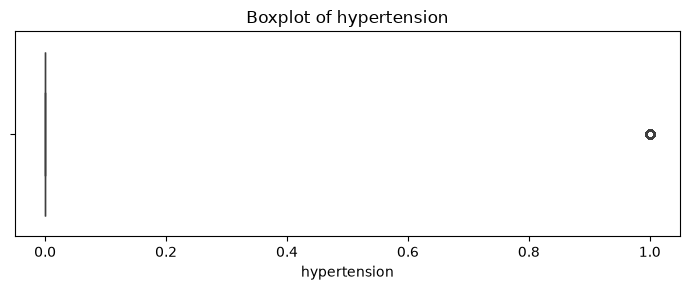

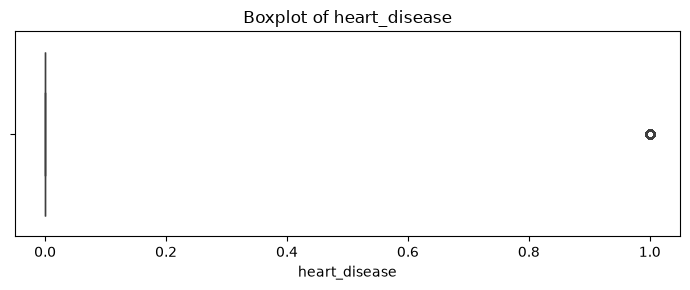

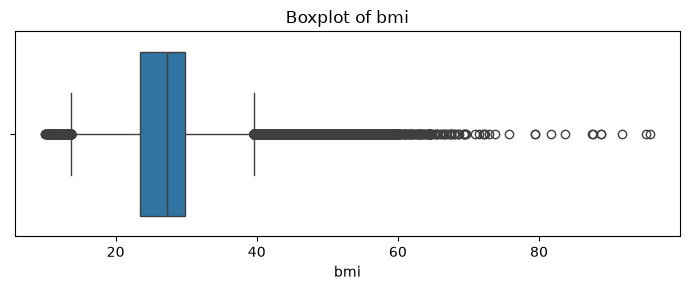

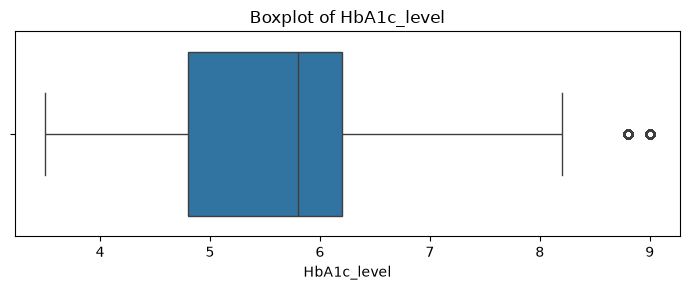

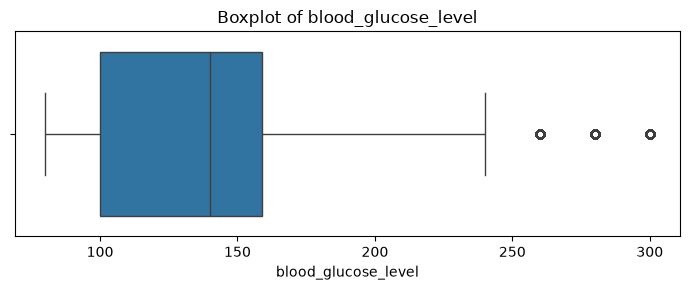

In [67]:
# ============================================================
# 3.7 BOXPLOTS FOR OUTLIER INSPECTION
# ============================================================

for col in numerical_features:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


### Outlier explanation

A boxplot helps identify observations that are far from the central range.

"However, an outlier is not automatically an error. In a medical dataset, an unusual value can represent a genuine patient measurement, so I did not blindly remove outliers."


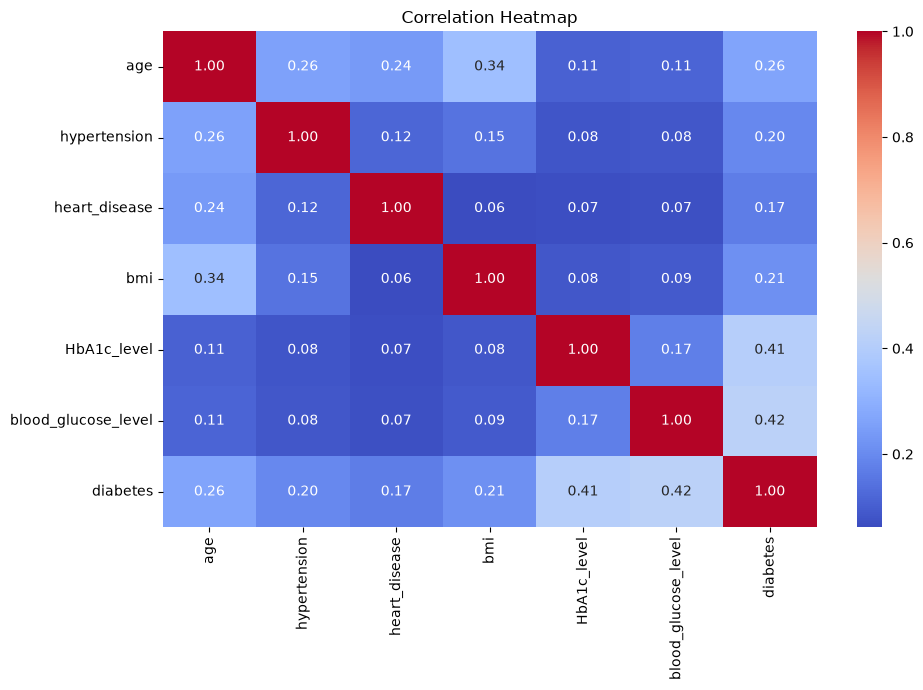

In [68]:
# ============================================================
# 3.8 CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### Correlation explanation

Correlation measures the linear relationship between numerical variables.

- Positive correlation: variables tend to increase together.
- Negative correlation: one tends to increase when the other decreases.
- Correlation close to 0: weak linear relationship.

Correlation does **not** prove causation.

"In my dataset, blood glucose level had the strongest positive linear correlation with the diabetes target at 0.4243, followed by HbA1c level at 0.4064."

"Age had a correlation of 0.2649, BMI 0.2149, hypertension 0.1957 and heart disease 0.1707."

"So blood glucose and HbA1c showed stronger linear associations with the diabetes target compared with the other numerical variables."


In [69]:
# ============================================================
# 3.9 DIABETES RATE BY IMPORTANT NUMERICAL FEATURES
# ============================================================

# Compare average values by target class.
df.groupby("diabetes")[numerical_features].mean().T


diabetes,0,1
age,39.943229,60.925961
hypertension,0.061314,0.245933
heart_disease,0.030297,0.149375
bmi,26.869003,31.997755
HbA1c_level,5.396936,6.934827
blood_glucose_level,132.818489,194.026173


This table gives a simple descriptive comparison between the two target classes.




# 4. Prepare X and y

- **X** = input/features used by the model
- **y** = target/output that the model predicts


In [70]:
# ============================================================
# 4. PREPARE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["diabetes"])
y = df["diabetes"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True).mul(100).round(2))


X shape: (96146, 8)
y shape: (96146,)

Target distribution:
diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64


#### Observation
"I separated the input features and target variable."

"X contains the 8 input features and y contains the diabetes target."

"After duplicate removal, X had 96,146 observations and 8 features, while y contained 96,146 target values."

# 5. Train-Test Split

We split the data before fitting preprocessing steps.

`stratify=y` is important because the target is imbalanced. It keeps approximately the same class proportions in both training and testing data.


In [71]:
# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=43,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


X_train: (76916, 8)
X_test : (19230, 8)
y_train: (76916,)
y_test : (19230,)

Training target distribution:
diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64

Testing target distribution:
diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64


> "I divided the cleaned dataset into training and testing data using an 80:20 split.The training set contained 76,916 observations, and the test set contained 19,230 observations.I used random_state=43 for reproducibility. I also used stratify=y because the target was imbalanced. This maintained the same 91.18% and 8.82% class proportions in both training and testing data."

# 6. Preprocessing with ColumnTransformer

The dataset contains both numerical and categorical features.

### Numerical features
We use:
- median imputation
- StandardScaler

### Categorical features
We use:
- most-frequent imputation
- OneHotEncoder

`ColumnTransformer` lets us apply the correct preprocessing to each type of column.

**Important:** The preprocessing is fitted only on training data through the pipeline. This helps prevent data leakage.


In [72]:
# ============================================================
# 6. PREPROCESSING
# ============================================================

numeric_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

print("Preprocessor created.")


Preprocessor created.


# 7. Handling Class Imbalance with SMOTE

**SMOTE = Synthetic Minority Over-sampling Technique.**

The minority class is the diabetic class (`1`).

SMOTE creates synthetic minority-class training examples instead of simply duplicating existing rows.

### Very important rule

We must apply SMOTE **only to the training data**.

The pipeline below performs:

`Preprocessing → SMOTE → Model`

inside the training process.

This prevents information from the test set leaking into training.


In [73]:
# ============================================================
# 7. CHECK CLASS COUNTS BEFORE SMOTE
# ============================================================

print("Before SMOTE:")
print(y_train.value_counts())


Before SMOTE:
diabetes
0    70130
1     6786
Name: count, dtype: int64


In [74]:
# Demonstration: what SMOTE does to the training target
X_train_processed = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=43)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Before SMOTE:
diabetes
0    70130
1     6786
Name: count, dtype: int64

After SMOTE:
diabetes
0    70130
1    70130
Name: count, dtype: int64


> “Because the target classes are imbalanced, I used SMOTE on the training data to create synthetic samples for the minority diabetic class. I did not apply SMOTE to the test set because the test set must represent unseen real-world data.”


# 8. Classification Algorithms

We will compare several commonly used classification algorithms:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. AdaBoost
7. Gaussian Naive Bayes
8. Linear SVM
9. XGBoost

Each model is placed in the same preprocessing + SMOTE pipeline so the comparison is more consistent.


In [75]:
# ============================================================
# 8. DEFINE MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=43
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=43
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        n_jobs=-1,
        random_state=43
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=43
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=43
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Linear SVM": LinearSVC(
        C=1.0,
        random_state=43
    ) ,

    "XGBoost" : XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=43,
        n_jobs=-1
    )
}

print("Models:", list(models.keys()))


Models: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'Gaussian Naive Bayes', 'Linear SVM', 'XGBoost']


> "I trained multiple classification algorithms because different algorithms learn patterns differently. I wanted to compare their performance on the same preprocessing and class-imbalance strategy."

## 9. Train all models and compare them

For every algorithm, we calculate:

- Accuracy
- Precision
- Recall
- F1-score
- Specificity
- ROC-AUC
- PR-AUC

### Why multiple metrics?

Because the dataset is imbalanced, accuracy by itself is not enough.

**Recall** answers: “Of the actual diabetic patients, how many did the model identify?”

**Precision** answers: “Of the people predicted as diabetic, how many were actually diabetic?”

**F1-score** balances precision and recall.

**Specificity** measures how well the model identifies non-diabetic cases.

**ROC-AUC** measures ranking/discrimination across thresholds.

**PR-AUC** is particularly informative when the positive class is relatively rare.


In [76]:
# ============================================================
# 9. TRAIN AND EVALUATE ALL MODELS
# ============================================================

def get_scores(model, X_test, y_test):
    y_pred = model.predict(X_test)

    # LinearSVC has decision_function instead of predict_proba.
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Specificity": specificity,
        "ROC_AUC": roc_auc_score(y_test, y_score),
        "PR_AUC": average_precision_score(y_test, y_score)
    }, y_pred, y_score


results = []
trained_models = {}
predictions = {}
scores_for_curves = {}

for name, estimator in models.items():

    # Pipeline order:
    # 1. preprocess columns
    # 2. apply SMOTE only on training data
    # 3. train classifier
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=43)),
        ("model", estimator)
    ])

    print(f"Training: {name}")
    pipe.fit(X_train, y_train)

    metrics, y_pred, y_score = get_scores(pipe, X_test, y_test)

    results.append({"Model": name, **metrics})
    trained_models[name] = pipe
    predictions[name] = y_pred
    scores_for_curves[name] = y_score

results_df = pd.DataFrame(results).sort_values(
    by="F1", ascending=False
).reset_index(drop=True)

results_df.round(4)


Training: Logistic Regression
Training: KNN
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Training: AdaBoost
Training: Gaussian Naive Bayes
Training: Linear SVM
Training: XGBoost


,Model,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,XGBoost,0.9685,0.8827,0.7412,0.8058,0.9905,0.9791,0.8887
1,Gradient Boosting,0.9542,0.7175,0.7936,0.7536,0.9698,0.9775,0.8836
2,Random Forest,0.9201,0.5281,0.8797,0.6600,0.9240,0.9755,0.8814
3,KNN,0.9123,0.5016,0.8178,0.6218,0.9214,0.9146,0.6207
4,AdaBoost,0.9045,0.4774,0.8715,0.6169,0.9077,0.9715,0.8614
5,Decision Tree,0.8850,0.4285,0.9092,0.5824,0.8827,0.9703,0.8398
6,Linear SVM,0.8855,0.4286,0.8950,0.5796,0.8846,0.9651,0.8313
7,Logistic Regression,0.8853,0.4282,0.8945,0.5791,0.8845,0.9650,0.8316
8,Gaussian Naive Bayes,0.4540,0.1383,0.9923,0.2428,0.4020,0.9152,0.5176


#### Observation

"XGBoost achieved 96.85% accuracy,88.27% precision, 74.12% recall, and 80.58% F1-score."

"Its ROC-AUC was 0.9791 and PR-AUC was 0.8887."

"Random Forest had lower accuracy at 92.01%, but its recall was higher at 87.97%."

"This means Random Forest identified a larger proportion of the actual diabetic cases, but it also had lower precision."

"So the results show a clear precision-recall trade-off."

> Do not choose a model using accuracy alone.
The appropriate final model should be selected based on the project objective and the metric that matters most, rather than simply choosing the highest accuracy.


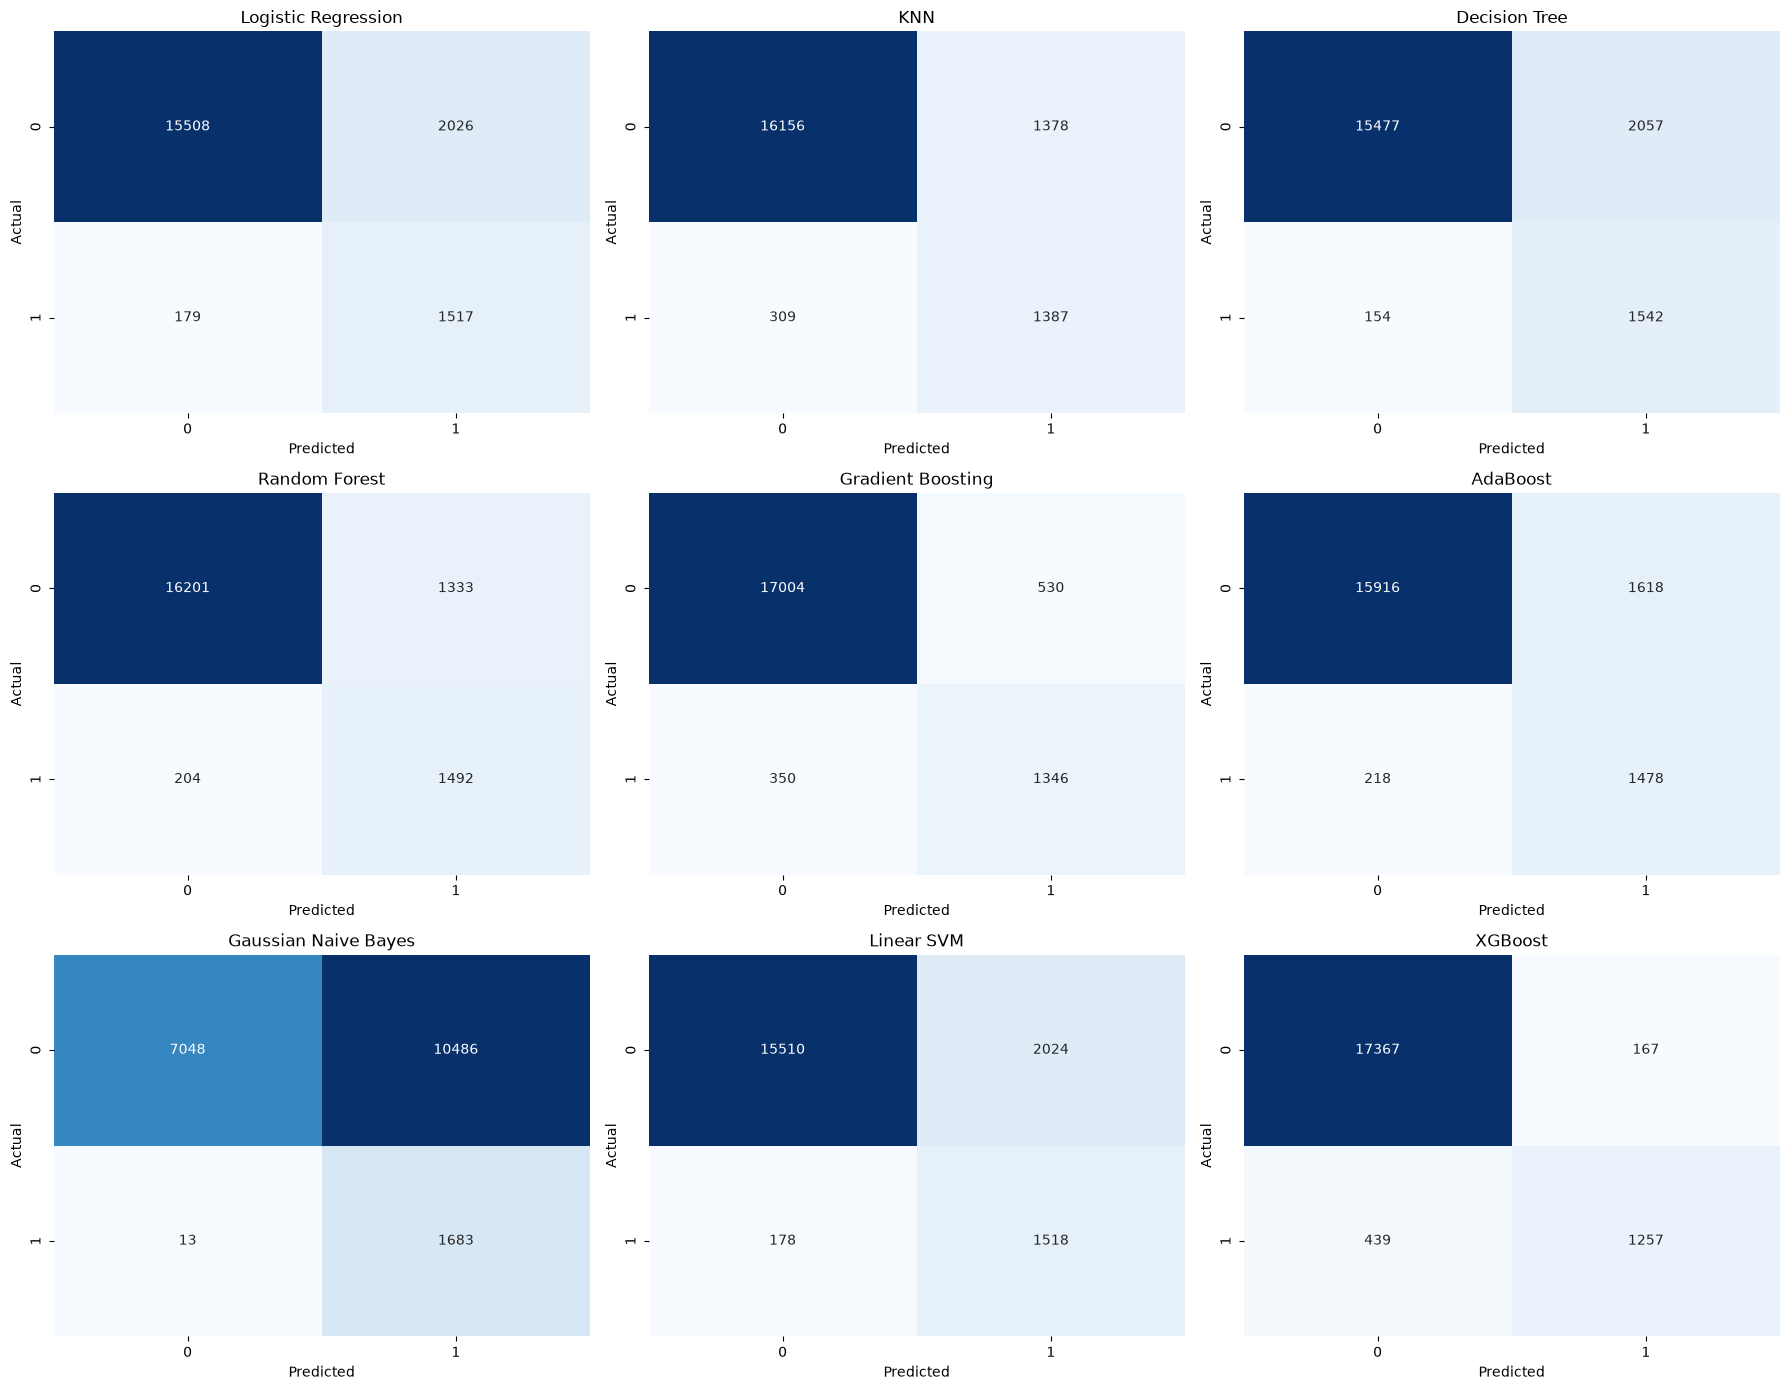

In [77]:
# ============================================================
# 10. CONFUSION MATRICES
# ============================================================

n_models = len(trained_models)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()


for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


### Confusion matrix

For binary classification:

- **True Positive (TP):** actual diabetic and predicted diabetic
- **True Negative (TN):** actual non-diabetic and predicted non-diabetic
- **False Positive (FP):** actual non-diabetic but predicted diabetic
- **False Negative (FN):** actual diabetic but predicted non-diabetic

For a diabetes screening use case, false negatives can be particularly important because they represent diabetic cases that the model failed to identify.


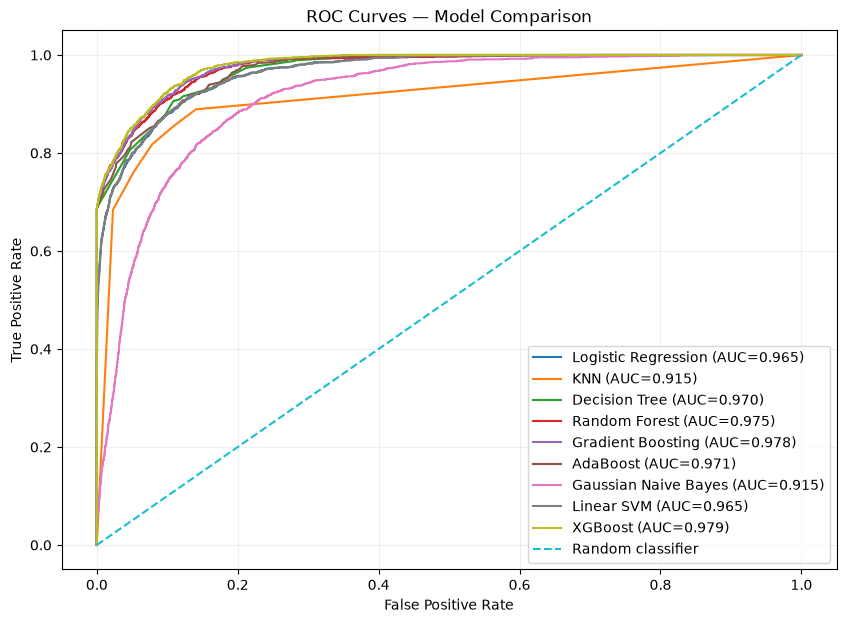

In [78]:
# ============================================================
# 11. ROC CURVES
# ============================================================

plt.figure(figsize=(10, 7))

for name, y_score in scores_for_curves.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### ROC-AUC explanation

"The ROC-AUC for XGBoost was 0.979."

"ROC-AUC evaluates how well the model separates the positive and negative classes across different classification thresholds."

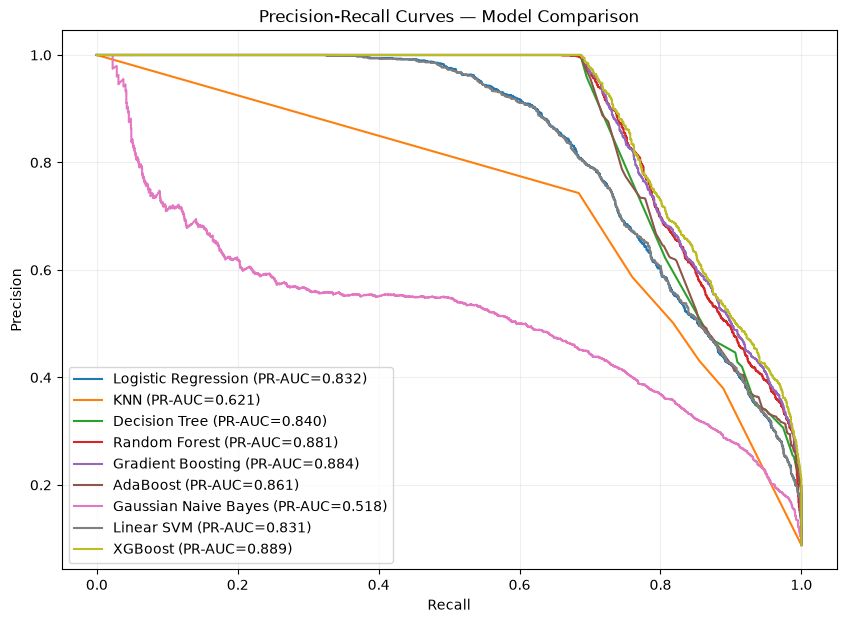

In [79]:
# ============================================================
# 12. PRECISION-RECALL CURVES
# ============================================================

plt.figure(figsize=(10, 7))

for name, y_score in scores_for_curves.items():
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### Why PR-AUC?

When the positive class is relatively rare, the precision-recall curve focuses directly on the positive class.

Here, diabetes is the minority/positive class, so PR-AUC provides useful information that complements ROC-AUC.


# 13. Detailed Classification Report

The classification report gives precision, recall and F1-score for each class.


In [80]:
# Choose a model for detailed inspection.
# Change this name after reviewing results_df.
MODEL_TO_INSPECT = results_df.loc[0, "Model"]

print("Model being inspected:", MODEL_TO_INSPECT)
print()
print(classification_report(
    y_test,
    predictions[MODEL_TO_INSPECT],
    target_names=["No Diabetes (0)", "Diabetes (1)"],
    zero_division=0
))


Model being inspected: XGBoost

                 precision    recall  f1-score   support

No Diabetes (0)       0.98      0.99      0.98     17534
   Diabetes (1)       0.88      0.74      0.81      1696

       accuracy                           0.97     19230
      macro avg       0.93      0.87      0.89     19230
   weighted avg       0.97      0.97      0.97     19230



# 14. Cross-Validation

A single train/test split can sometimes give a result that depends on that particular split.

Stratified K-Fold cross-validation evaluates the model over multiple training/validation splits while preserving class proportions.

We use it here on the training data.


In [81]:
# ============================================================
# 14. STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=43
)

# Cross-validation on a few representative models.
# This avoids making the notebook unnecessarily slow.
cv_models = {
    "Logistic Regression": trained_models["Logistic Regression"],
    "Random Forest": trained_models["Random Forest"],
    "Gradient Boosting": trained_models["Gradient Boosting"], 
    "XGBoost": trained_models["XGBoost"]
}

cv_results = []

for name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(cv_results)
cv_df.round(4)


,Model,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean
0,Logistic Regression,0.8854,0.4275,0.8770,0.5747,0.9609
1,Random Forest,0.9191,0.5253,0.8668,0.6541,0.9722
2,Gradient Boosting,0.9560,0.7387,0.7750,0.7564,0.9754
3,XGBoost,0.9667,0.8818,0.7197,0.7925,0.9771


# 15. Feature Importance / Model Interpretation
Remember: **feature importance is not the same as causation.**


In [82]:
# ============================================================
# 15. XGBoost FEATURE IMPORTANCE
# ============================================================

xgb_pipe = trained_models["XGBoost"]

feature_names = xgb_pipe.named_steps["preprocessor"].get_feature_names_out()
xgb_model = xgb_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df.head(15)


,Feature,Importance
4,num__HbA1c_level,0.423707
5,num__blood_glucose_level,0.279138
0,num__age,0.114475
1,num__hypertension,0.051160
3,num__bmi,0.048417
9,cat__smoking_history_No Info,0.027040
2,num__heart_disease,0.025410
7,cat__gender_Male,0.009621
12,cat__smoking_history_former,0.004801
13,cat__smoking_history_never,0.004436


#### Observation

"I used xgb feature importance to understand which transformed features contributed most to the model's predictions."

"The most important feature was HbA1c level with an importance of 0.423707, followed by blood glucose level at 0.2791, and age at 0.114475."

"BMI had an importance of approximately 0.0484."

"This tells me which features contributed more to the xgb model predictions, but it should not be interpreted as proof of causation."

##### Very important distinction:

Heatmap showed:

Blood glucose correlation = 0.4243

but xgb model feature importance showed:

HbA1c importance = 0.4231

"Correlation and feature importance are different concepts. Correlation measures linear association, whereas tree-based feature importance measures how much a feature contributes to the model's predictive decisions."

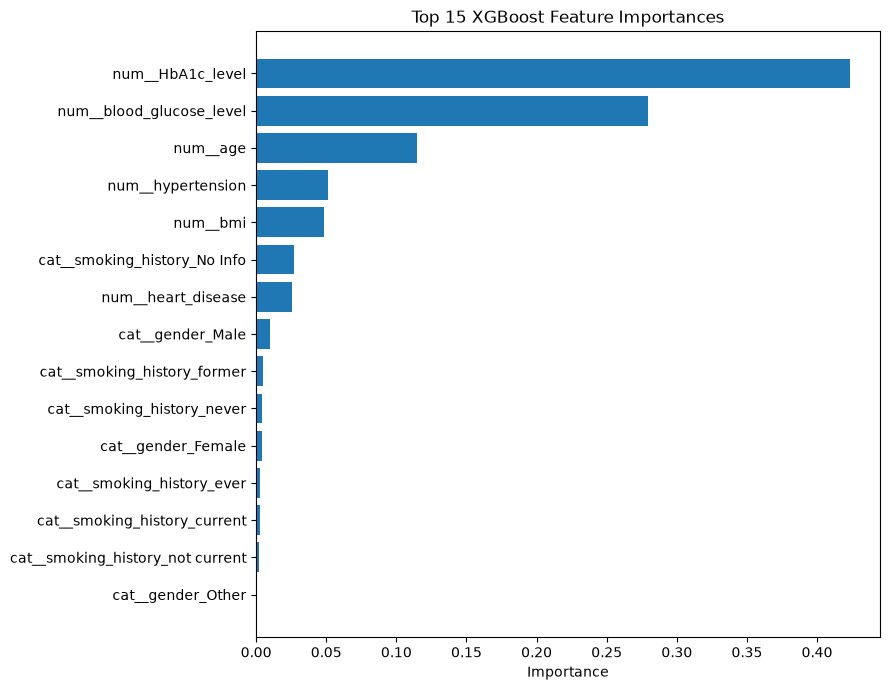

In [83]:
# Plot top 15 xgb model features
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()


# 16. Save the final model

I saved the complete pipeline using Joblib.

The complete pipeline is saved, including:
- preprocessing
- SMOTE
- model

"This means when new data is provided, the same preprocessing steps can be applied consistently."


In [84]:
# ============================================================
# 17. SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_NAME = MODEL_TO_INSPECT
final_model = trained_models[FINAL_MODEL_NAME]

joblib.dump(
    final_model,
    "diabetic_prediction_pipeline_1.pkl"
)

print("Saved:", "diabetic_prediction_pipeline_1.pkl")
print("Final model:", FINAL_MODEL_NAME)


Saved: diabetic_prediction_pipeline_1.pkl
Final model: XGBoost


# 17. Load the saved model and make a prediction


In [85]:
# ============================================================
# 18. LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load("diabetic_prediction_pipeline_1.pkl")

print("Loaded model:", loaded_model)


Loaded model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                

In [86]:
# Example diabetic cases record
new_patient = pd.DataFrame([{
    "gender": "Female",
    "age": 54,
    "hypertension": 0,
    "heart_disease": 0,
    "smoking_history": "never",
    "bmi": 27.32,
    "HbA1c_level": 6.6,
    "blood_glucose_level": 140
}])

prediction = loaded_model.predict(new_patient)[0]

if hasattr(loaded_model, "predict_proba"):
    probability = loaded_model.predict_proba(new_patient)[0, 1]
else:
    probability = None

print("Predicted class:", prediction)

if probability is not None:
    print(f"Predicted diabetes probability: {probability:.2%}")

print("0 = No Diabetes")
print("1 = Diabetes")


Predicted class: 0
Predicted diabetes probability: 18.43%
0 = No Diabetes
1 = Diabetes


> "The model predicted class 0, meaning no diabetes, with a predicted diabetes probability of 18.43%."

> "This is only a machine-learning prediction and not a medical diagnosis."

# 18. PROJECT CONCLUSION

### Conclusion

In this project, I developed a machine-learning classification pipeline to predict diabetes.

- The dataset initially contained 100,000 records.
- I removed exact duplicate records and obtained 96,146 records.
- There were no missing values in the cleaned dataset.
- The target variable was imbalanced, with 91.18% non-diabetes records and 8.82% diabetes records.
- I used an 80:20 stratified train-test split.
- Numerical features were processed using median imputation and StandardScaler.
- Categorical features were processed using most-frequent imputation and One-Hot Encoding.
- SMOTE was applied only to the training data to address class imbalance.
- I compared nine classification algorithms, including XGBoost.
- I evaluated the models using accuracy, precision, recall, F1-score, specificity, ROC-AUC and PR-AUC.
- XGBoost achieved an F1-score of 80.58%, ROC-AUC of 0.9791 and PR-AUC of 0.8887 on the test set.
- Based on the F1-score comparison, XGBoost was selected as the final model.
- The complete preprocessing and model pipeline was saved using Joblib for reuse.

### Final Note

This project demonstrates a machine-learning prediction workflow and is intended for educational and portfolio purposes. The model prediction should not be considered a medical diagnosis or a replacement for professional medical evaluation.